# Fine-Tuning Llama 2 with QLoRA — A Step-by-Step Guide

> **Curriculum position:** Notebook 11 of 11 — the capstone of the *AI Researcher Basic* series.  
> **Prerequisites:** You should be comfortable with the concepts covered in the earlier notebooks:  
> `0. math` → `1. derivatives` → `2. vectors` → `3. gradient` → `4. matrix` → `tensors_1–5` → `neural_network/single_neuron` → `neural_network/neuron_layers` → `neural_network/2_multi_neuron_layers_&_math`

---

## What This Notebook Does

We take **Llama 2 7B Chat** — a 7-billion-parameter language model — and teach it new behaviour on a small instruction-following dataset using a technique called **QLoRA** (Quantized Low-Rank Adaptation). By the end you will have:

1. A fine-tuned model that responds differently (and better, for the target domain) than the base model
2. A complete understanding of *every line of code*, not just copy-paste knowledge
3. A merged, deployment-ready set of model weights

---

## Hardware Requirements

| Configuration | Min VRAM | Notes |
|---|---|---|
| 4-bit quantization + LoRA (this notebook) | ~12 GB | Google Colab T4 (free), Kaggle P100 |
| 8-bit quantization + LoRA | ~16 GB | Colab Pro A10 |
| Full fine-tuning fp16 | ~80 GB | A100 80 GB |
| Full fine-tuning fp32 | ~112 GB | Multi-GPU setup |

**You can run this notebook for free** on [Google Colab](https://colab.research.google.com) (Runtime → Change runtime type → T4 GPU) or [Kaggle](https://kaggle.com/kernels) (Accelerator → GPU P100).

---

## Table of Contents

1. [Background: The Fine-Tuning Landscape](#1-background)
2. [QLoRA: Quantization + LoRA Combined](#2-qlora)
3. [Environment Setup](#3-setup)
4. [Imports](#4-imports)
5. [Configuration Block](#5-config)
6. [Dataset Loading & Exploration](#6-dataset)
7. [Quantization Configuration](#7-quantization)
8. [Load Base Model](#8-model)
9. [LoRA Configuration](#9-lora)
10. [Tokenizer Setup](#10-tokenizer)
11. [Training Arguments](#11-training-args)
12. [SFTTrainer Initialization](#12-trainer)
13. [Pre-Training Baseline Inference](#13-baseline)
14. [Training](#14-train)
15. [Training Loss Visualization](#15-loss)
16. [Post-Training Inference & Comparison](#16-compare)
17. [Memory Cleanup](#17-cleanup)
18. [Merge LoRA Weights into Base Model](#18-merge)
19. [Save & (Optional) Push to Hub](#19-save)
20. [References & Further Reading](#20-references)

<a id='1-background'></a>
## 1. Background: The Fine-Tuning Landscape

### What is fine-tuning?

A large language model like Llama 2 is first **pre-trained** on hundreds of billions of tokens of text from the internet, books, and code. This costs millions of dollars in compute and takes weeks on thousands of GPUs. The result is a model that has a very broad understanding of language — but it has no idea about your specific task, domain, or desired output style.

**Fine-tuning** is the process of continuing to train this pre-trained model on a much smaller, task-specific dataset so that it learns the target behaviour. Think of it like hiring a broadly educated person and then giving them on-the-job training for a specific role.

### Three ways to adapt a pre-trained LLM

| Method | How it works | Cost | Use when |
|---|---|---|---|
| **In-context learning** | Put examples in the prompt | Free, no training | Task is simple, few examples needed |
| **Fine-tuning** | Train on labelled examples | Medium | Consistent style, domain knowledge |
| **Pre-training from scratch** | Train on raw text from zero | Enormous | Truly novel domain, e.g. a new language |

### The problem with full fine-tuning

Llama 2 7B has **7 billion parameters**. In full fine-tuning, every parameter is updated during training. The memory required is:

```
Model weights (fp32):  7B × 4 bytes = 28 GB
Gradients (fp32):      7B × 4 bytes = 28 GB
Optimizer states (Adam has 2 moments per param):
                       7B × 8 bytes = 56 GB
─────────────────────────────────────────────
Total minimum:                      ~112 GB
```

That requires **multiple A100 80 GB GPUs** — not something most researchers have access to.

### Parameter-Efficient Fine-Tuning (PEFT)

The key insight: **you don't need to update all 7 billion parameters**. Most of the model's knowledge is already in the pre-trained weights. We only need to teach it a small delta — a change in direction.

The PEFT family of methods do exactly this:

- **LoRA** (Low-Rank Adaptation): add small trainable matrices alongside the frozen weights ← *what we use*
- **Prefix Tuning**: prepend trainable tokens to the input
- **Adapter layers**: insert small trainable modules between transformer layers

LoRA achieves near full fine-tuning quality while only training **~1–3% of parameters**.

> **Reference:** Hu et al. (2022). *LoRA: Low-Rank Adaptation of Large Language Models.* arXiv:2106.09685

<a id='2-qlora'></a>
## 2. QLoRA: Quantization + LoRA Combined

### What is Quantization?

Quantization is the process of reducing the numerical precision of model weights. Instead of storing each weight as a 32-bit float (which can represent ~4 billion distinct values), we store it as a 4-bit integer (which can represent only 16 distinct values).

```
float32: [████████████████████████████████]  4 bytes per weight
float16: [████████████████]                  2 bytes per weight
 int8:   [████████]                          1 byte per weight
 nf4:    [████]                              0.5 bytes per weight  ← QLoRA uses this
```

**Memory comparison for Llama 2 7B:**
```
float32:  7B × 4 bytes = 28.0 GB
float16:  7B × 2 bytes = 14.0 GB
int8:     7B × 1 byte  =  7.0 GB
nf4:      7B × 0.5B    =  3.5 GB   ← fits on almost any GPU!
```

### NF4: Normal Float 4

Naively storing weights as 4-bit integers would lose too much precision. QLoRA uses a smarter scheme called **NF4 (Normal Float 4)**, which places the 16 quantization levels non-uniformly — more levels near zero (where most weights cluster) and fewer levels in the tails.

This is information-theoretically optimal for normally distributed weights \[1\].

### The QLoRA Trick: Separate Storage from Computation

Weights are **stored** in 4-bit NF4 to save memory, but are **dequantized to fp16** just-in-time during the forward pass for the actual computation. LoRA adapters (the small trainable matrices) are kept in full fp16 throughout.

```
┌──────────────────────────────────────────────────────┐
│                  Transformer Block                   │
│                                                      │
│  Frozen weights W₀ (stored in nf4, ~0.5 bytes/param)│
│       +                                              │
│  LoRA adapter:  A (fp16) × B (fp16)  ← only ~1-3%  │
│       of parameters are trainable                    │
│                                                      │
│  Output = W₀·x  +  (B·A)·x·(α/r)                   │
└──────────────────────────────────────────────────────┘
```

Result: we can fine-tune Llama 2 7B on a **single 12 GB GPU** with negligible quality loss.

> **Reference:** Dettmers et al. (2023). *QLoRA: Efficient Finetuning of Quantized LLMs.* arXiv:2305.14314


<a id='3-setup'></a>
## 3. Environment Setup

### What we're installing

| Package | Role |
|---|---|
| `transformers` | Model architectures, tokenizers, `AutoModel`, `pipeline` |
| `peft` | LoRA and other PEFT methods (`LoraConfig`, `PeftModel`) |
| `trl` | Supervised fine-tuning trainer (`SFTTrainer`) |
| `bitsandbytes` | 4-bit and 8-bit quantization (`BitsAndBytesConfig`) |
| `accelerate` | Distributed training and device management under the hood |
| `datasets` | Hugging Face dataset loading and processing |
| `matplotlib` | Inline training loss curve visualization |

We intentionally do **not** pin versions so you always get the latest stable releases with security patches. If you need reproducibility, run `pip freeze > requirements.txt` after installation.

> **Google Colab users:** After the install cell finishes, go to **Runtime → Restart session** (or press `Ctrl+M .`) and then **Run all** cells again from the top. This ensures the newly installed package versions are picked up correctly by the Python kernel.

> **Colab T4 note:** The free T4 GPU has 15 GB VRAM. With 4-bit quantization the model occupies ~4–5 GB, leaving ~10 GB for activations and optimizer states — sufficient for `BATCH_SIZE=4`. If you get an OOM error, set `BATCH_SIZE=2` and `GRADIENT_ACCUM_STEPS=2` to keep the effective batch size at 4.


In [1]:
print("=" * 60)
print("STEP 1/10 — Installing packages")
print("=" * 60)

try:
    import subprocess, sys

    # bitsandbytes is NOT pinned — it must match the CUDA version Colab provides.
    # All other packages are pinned for reproducibility.
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "transformers==4.44.2",
         "peft==0.12.0",
         "trl==0.9.6",
         "bitsandbytes",          # latest — must match Colab's CUDA (currently 12.8)
         "accelerate==0.33.0",
         "datasets==2.21.0",
         "matplotlib"],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("❌ pip install failed:")
        print(result.stderr)
    else:
        # Print the bitsandbytes version that was installed
        r2 = subprocess.run(
            [sys.executable, "-m", "pip", "show", "bitsandbytes"],
            capture_output=True, text=True
        )
        for line in r2.stdout.splitlines():
            if line.startswith("Version"):
                print(f"✓ bitsandbytes {line}")
        print("✓ All other packages installed at pinned versions.")
        print("⚠️  If on Google Colab: Runtime → Restart session → Run all")

except Exception as e:
    print(f"❌ Unexpected error during install: {e}")

STEP 1/10 — Installing packages
✓ bitsandbytes Version: 0.49.2
✓ All other packages installed at pinned versions.
⚠️  If on Google Colab: Runtime → Restart session → Run all


In [2]:

# ─── OPTIONAL: Mount Google Drive to persist your model across Colab sessions ──
#
# By default, Colab saves everything to /content/ which is wiped when the session
# ends or disconnects. If training takes 30 minutes you do NOT want to lose the
# checkpoint — mount your Google Drive and save there instead.
#
# How to use:
#   1. Set USE_DRIVE = True
#   2. Run this cell — a popup will ask you to authorise Drive access
#   3. The OUTPUT_DIR and SAVE_DIR variables will automatically point to Drive

import os

USE_DRIVE = True   # ← change to True to enable Drive storage

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DRIVE_BASE = "/content/drive/MyDrive/llama2_finetune"
        os.makedirs(DRIVE_BASE, exist_ok=True)
        # Override paths to write to Drive
        OUTPUT_DIR = f"{DRIVE_BASE}/results"
        NEW_MODEL  = f"{DRIVE_BASE}/Llama-2-7b-chat-finetune"
        print(f"Google Drive mounted.")
        print(f"  Checkpoints : {OUTPUT_DIR}")
        print(f"  Adapter     : {NEW_MODEL}")
    except ImportError:
        print("Not on Google Colab — Drive mount skipped.")
else:
    # Local / default paths (files stay in /content/ on Colab, or current dir locally)
    OUTPUT_DIR = "./results"
    NEW_MODEL  = "Llama-2-7b-chat-finetune"
    print("Drive not mounted. Files saved to current working directory.")
    print("Set USE_DRIVE = True above to persist across Colab sessions.")


Mounted at /content/drive
Google Drive mounted.
  Checkpoints : /content/drive/MyDrive/llama2_finetune/results
  Adapter     : /content/drive/MyDrive/llama2_finetune/Llama-2-7b-chat-finetune


In [3]:
# Hardware check — run this to confirm your GPU is visible and has enough VRAM
import subprocess, sys

try:
    import torch
    if torch.cuda.is_available():
        gpu_name  = torch.cuda.get_device_name(0)
        vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
        cuda_ver  = torch.version.cuda
        torch_ver = torch.__version__
        print(f"GPU  : {gpu_name}")
        print(f"VRAM : {vram_gb:.1f} GB")
        print(f"CUDA : {cuda_ver}")
        print(f"PyTorch: {torch_ver}")
        if vram_gb < 12:
            print("\n⚠️  Warning: Less than 12 GB VRAM detected.")
            print("   Suggestions:")
            print("   - Reduce BATCH_SIZE to 2 or 1")
            print("   - Increase GRADIENT_ACCUM_STEPS to compensate")
            print("   - Use a smaller model (e.g. Llama 2 3B or Phi-2)")
        else:
            print("\n✓  VRAM looks sufficient for 4-bit fine-tuning!")
    else:
        print("❌  No CUDA GPU detected. This notebook requires a GPU.")
        print("   If on Colab: Runtime → Change runtime type → T4 GPU")
except ImportError:
    print("PyTorch not found. Please restart the runtime after installing packages.")

GPU  : Tesla T4
VRAM : 15.6 GB
CUDA : 12.8
PyTorch: 2.11.0+cu128

✓  VRAM looks sufficient for 4-bit fine-tuning!


<a id='4-imports'></a>
## 4. Imports

We group imports by category so it's easy to see which library provides what. Take a moment to read the comments — understanding *what each import does* before you use it makes debugging much easier.

In [4]:
print("=" * 60)
print("STEP 2/10 — Importing libraries")
print("=" * 60)

try:
    import gc
    import warnings
    import matplotlib.pyplot as plt
    print("✓ gc, warnings, matplotlib")

    import torch
    print(f"✓ torch {torch.__version__}")

    from datasets import load_dataset
    import datasets as ds_lib
    print(f"✓ datasets {ds_lib.__version__}")

    from transformers import (
        AutoModelForCausalLM,
        AutoTokenizer,
        BitsAndBytesConfig,
        TrainingArguments,
        pipeline,
        logging as hf_logging,
    )
    import transformers
    print(f"✓ transformers {transformers.__version__}")

    from peft import (
        LoraConfig,
        PeftModel,
        get_peft_model,
        prepare_model_for_kbit_training,
    )
    import peft
    print(f"✓ peft {peft.__version__}")

    from trl import SFTTrainer, SFTConfig
    import trl
    print(f"✓ trl {trl.__version__}")

    import bitsandbytes as bnb
    print(f"✓ bitsandbytes {bnb.__version__}")

    hf_logging.set_verbosity_warning()
    warnings.filterwarnings("ignore")

    print("\n✓ All imports successful.")

except ImportError as e:
    print(f"\n❌ Import failed: {e}")
    print("   → Did you restart the session after the install cell?")

STEP 2/10 — Importing libraries
✓ gc, warnings, matplotlib
✓ torch 2.11.0+cu128
✓ datasets 2.21.0
✓ transformers 4.44.2
✓ peft 0.12.0
✓ trl 0.9.6
✓ bitsandbytes 0.49.2

✓ All imports successful.


<a id='5-config'></a>
## 5. Configuration Block — All Hyperparameters in One Place

A common best practice is to define **all tunable knobs at the top of the notebook** in one place. This way, if you want to experiment ("what happens if I double the LoRA rank?"), you only need to change one variable rather than hunting through multiple cells.

Read through the comments carefully — each parameter has a note explaining what changing it does.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL
# ═══════════════════════════════════════════════════════════════════════════
MODEL_ID  = "NousResearch/Llama-2-7b-chat-hf"
# NousResearch mirrors Meta's Llama 2 without requiring a HF access token.
# Swap this to "meta-llama/Llama-2-7b-chat-hf" if you have a token and want
# the official weights (same architecture, gated access).

NEW_MODEL = "Llama-2-7b-chat-finetune"
# Local directory name where the fine-tuned LoRA adapter will be saved.

# ═══════════════════════════════════════════════════════════════════════════
# DATASET
# ═══════════════════════════════════════════════════════════════════════════
DATASET_ID = "mlabonne/guanaco-llama2-1k"
# This is the Guanaco instruction-following dataset, already reformatted to
# match the Llama 2 chat template. 1,000 examples — small enough to train in
# ~30 min on a T4. For better quality, try "mlabonne/guanaco-llama2" (~10k).

# ═══════════════════════════════════════════════════════════════════════════
# LoRA HYPERPARAMETERS
# ═══════════════════════════════════════════════════════════════════════════
LORA_R       = 64
# Rank of the LoRA update matrices (r in the paper).
# Lower r → fewer params, faster training, possibly lower quality.
# Higher r → more expressive, but more memory and risk of overfitting.
# Common values: 8, 16, 32, 64. Start with 16 or 64.

LORA_ALPHA   = 16
# Scaling factor applied to the LoRA output: effective_scale = alpha / r.
# With r=64, alpha=16 → scale=0.25. This controls how strongly the adapter
# overrides the base model. Often set to r/4 or r/2.

LORA_DROPOUT = 0.1
# Dropout applied to LoRA layers during training (regularization).
# Prevents overfitting on small datasets. Set to 0.0 for large datasets.

# ═══════════════════════════════════════════════════════════════════════════
# QUANTIZATION
# ═══════════════════════════════════════════════════════════════════════════
USE_4BIT          = True
# Load base model weights in 4-bit precision (massive VRAM saving).
# Set to False only if you have >28 GB VRAM and want full fp32.

BNB_COMPUTE_DTYPE = "float16"
# Dtype for the dequantized computation during forward/backward passes.
# Use "bfloat16" on A100/H100 GPUs (better numerical stability).
# Use "float16" on T4/V100/P100 (no bfloat16 support on older GPUs).

BNB_QUANT_TYPE    = "nf4"
# Quantization scheme: "nf4" (Normal Float 4, optimal for normally distributed
# weights) or "fp4" (Float Point 4, simpler but less accurate). Use nf4.

USE_NESTED_QUANT  = False
# Double quantization: quantize the quantization constants themselves.
# Saves ~0.4 bits/parameter more at cost of slight additional computation.
# Can set to True if you're very tight on memory.

# ═══════════════════════════════════════════════════════════════════════════
# TRAINING HYPERPARAMETERS
# ═══════════════════════════════════════════════════════════════════════════
OUTPUT_DIR               = "./results"    # Where checkpoints and logs are saved
NUM_EPOCHS               = 1              # 1 pass through the 1k dataset
BATCH_SIZE               = 4             # Samples processed per gradient step
GRADIENT_ACCUM_STEPS     = 1             # Effective batch = BATCH_SIZE × this
                                          # Use 2–8 if BATCH_SIZE is forced to 1
LEARNING_RATE            = 2e-4          # Step size for the optimizer
                                          # Typical LoRA range: 1e-4 to 5e-4
WEIGHT_DECAY             = 0.001         # L2 regularization (penalises large weights)
MAX_GRAD_NORM            = 0.3           # Gradient clipping threshold
                                          # Prevents exploding gradients (NaN loss)
WARMUP_RATIO             = 0.03          # Fraction of steps for LR warm-up
                                          # LR ramps from 0 to LEARNING_RATE over
                                          # the first 3% of training steps
LR_SCHEDULER             = "cosine"      # Cosine annealing: LR decays smoothly
                                          # from peak back toward 0 after warm-up
OPTIMIZER                = "paged_adamw_32bit"
                                          # AdamW with paged memory — moves optimizer
                                          # states to CPU RAM when not needed, avoiding
                                          # GPU OOM spikes
MAX_SEQ_LENGTH           = 1024          # Maximum token length per training example
PACKING                  = False         # If True, pack multiple short examples into
                                          # one sequence for efficiency. False is safer
                                          # for datasets with mixed lengths.

print("Configuration loaded.")
print(f"  Model  : {MODEL_ID}")
print(f"  Dataset: {DATASET_ID}")
print(f"  LoRA r : {LORA_R}  |  alpha: {LORA_ALPHA}  |  scale: {LORA_ALPHA/LORA_R:.4f}")
print(f"  Quant  : {BNB_QUANT_TYPE} 4-bit, compute in {BNB_COMPUTE_DTYPE}")
print(f"  LR     : {LEARNING_RATE}  |  Epochs: {NUM_EPOCHS}  |  Batch: {BATCH_SIZE}")

Configuration loaded.
  Model  : NousResearch/Llama-2-7b-chat-hf
  Dataset: mlabonne/guanaco-llama2-1k
  LoRA r : 64  |  alpha: 16  |  scale: 0.2500
  Quant  : nf4 4-bit, compute in float16
  LR     : 0.0002  |  Epochs: 1  |  Batch: 4


<a id='6-dataset'></a>
## 6. Dataset Loading & Exploration

### What is the Guanaco dataset?

Guanaco is a subset of the **OpenAssistant Conversations** dataset \[4\], a large collection of human-written multi-turn dialogues in many languages. The version we use (`mlabonne/guanaco-llama2-1k`) has already been:

1. Filtered to 1,000 high-quality examples
2. Reformatted to match the **Llama 2 Chat template**

### The Llama 2 Chat Template

Llama 2 was fine-tuned with a very specific prompt format. If you deviate from it, the model gets confused. The format is:

```
<s>[INST] <<SYS>>
{system_message}
<</SYS>>

{user_message} [/INST] {model_response} </s>
```

- `<s>` / `</s>` — start-of-sequence and end-of-sequence tokens
- `[INST]` / `[/INST]` — marks the user instruction
- `<<SYS>>` / `<</SYS>>` — optional system prompt (sets the assistant's persona)

During fine-tuning we train the model to predict the model_response tokens, given everything before `[/INST]`. The instruction tokens are treated as context (not supervised), only the response is used to compute the loss.

In [6]:
print("=" * 60)
print("STEP 3/10 — Loading dataset")
print("=" * 60)

try:
    dataset = load_dataset(DATASET_ID, split="train")
    print(f"✓ Dataset loaded: {len(dataset)} examples")
    print(f"  Columns  : {dataset.column_names}")
    print(f"  Features : {dataset.features}")
except Exception as e:
    print(f"❌ Dataset loading failed: {e}")
    print("   → Check your internet connection or that DATASET_ID is correct.")

STEP 3/10 — Loading dataset


Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

✓ Dataset loaded: 1000 examples
  Columns  : ['text']
  Features : {'text': Value(dtype='string', id=None)}


In [7]:
# Print 2 examples to understand the data structure
for i, example in enumerate(dataset.select(range(2))):
    print(f"{'='*60}")
    print(f"EXAMPLE {i+1}")
    print(f"{'='*60}")
    print(example["text"])
    print()

EXAMPLE 1
<s>[INST] Me gradué hace poco de la carrera de medicina ¿Me podrías aconsejar para conseguir rápidamente un puesto de trabajo? [/INST] Esto vale tanto para médicos como para cualquier otra profesión tras finalizar los estudios aniversarios y mi consejo sería preguntar a cuántas personas haya conocido mejor. En este caso, mi primera opción sería hablar con otros profesionales médicos, echar currículos en hospitales y cualquier centro de salud. En paralelo, trabajaría por mejorar mi marca personal como médico mediante un blog o formas digitales de comunicación como los vídeos. Y, para mejorar las posibilidades de encontrar trabajo, también participaría en congresos y encuentros para conseguir más contactos. Y, además de todo lo anterior, seguiría estudiando para presentarme a las oposiciones y ejercer la medicina en el sector público de mi país. </s>

EXAMPLE 2
<s>[INST] Самый великий человек из всех живших на планете? [/INST] Для начала нужно выбрать критерии величия человека.

Character length — min: 58  |  mean: 1,499  |  max: 11,443


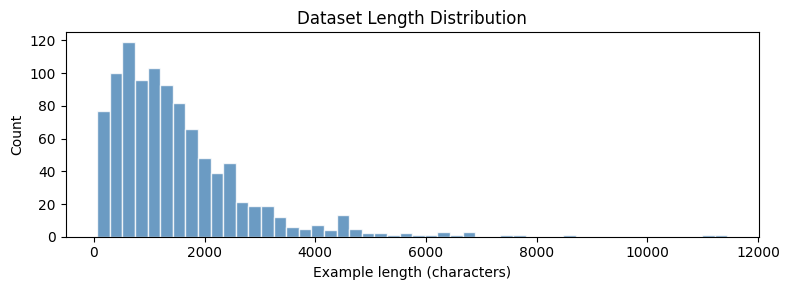

In [8]:
# Compute a rough length distribution (in characters, before tokenization)
lengths = [len(ex["text"]) for ex in dataset]
print(f"Character length — min: {min(lengths):,}  |  mean: {sum(lengths)//len(lengths):,}  |  max: {max(lengths):,}")

# Visualise the distribution
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
plt.xlabel("Example length (characters)")
plt.ylabel("Count")
plt.title("Dataset Length Distribution")
plt.tight_layout()
plt.show()

<a id='7-quantization'></a>
## 7. Quantization Configuration

### What does `BitsAndBytesConfig` do?

This configuration object is passed to `from_pretrained()` and instructs the model loader to:

1. **Intercept the normal weight loading** — instead of storing weights in fp32/fp16 as usual, quantize them to 4-bit NF4 before placing them in VRAM
2. **Register a dequantization hook** — during the forward pass, each 4-bit block is dequantized back to fp16 just before the matrix multiply, then the result is stored
3. **Keep LoRA adapters in fp16** — the trainable adapter matrices A and B are always in fp16 (not quantized), since they are small and we need full-precision gradients through them

### NF4 vs FP4

Both are 4-bit schemes, but they place their 16 quantization levels differently:

- **FP4**: places levels on a regular floating-point grid
- **NF4**: places more levels near zero (where neural network weights are densest) using quantiles of the normal distribution

NF4 gives lower quantization error for normally distributed weights — which pre-trained LLM weights are.

> From our earlier notebook `2_multi_neuron_layers_&_math.ipynb`: recall that proper weight initialisation (Xavier/He) ensures weights stay approximately normally distributed throughout training. QLoRA's NF4 exploits exactly this property.

In [9]:
print("=" * 60)
print("STEP 4/10 — Quantization config")
print("=" * 60)

try:
    compute_dtype = getattr(torch, BNB_COMPUTE_DTYPE)

    bnb_config = BitsAndBytesConfig(
        load_in_4bit              = USE_4BIT,
        bnb_4bit_quant_type       = BNB_QUANT_TYPE,
        bnb_4bit_compute_dtype    = compute_dtype,
        bnb_4bit_use_double_quant = USE_NESTED_QUANT,
    )

    if compute_dtype == torch.float16 and USE_4BIT:
        major, _ = torch.cuda.get_device_capability()
        if major >= 8:
            print("⚠️  GPU supports bfloat16 but we are using float16 for T4 compatibility.")
        else:
            print("✓ float16 is correct for this GPU (no bfloat16 support).")

    print(f"✓ BitsAndBytesConfig created:")
    print(f"  4-bit loading      : {bnb_config.load_in_4bit}")
    print(f"  Quantization type  : {bnb_config.bnb_4bit_quant_type}")
    print(f"  Compute dtype      : {bnb_config.bnb_4bit_compute_dtype}")
    print(f"  Double quantization: {bnb_config.bnb_4bit_use_double_quant}")

except Exception as e:
    print(f"❌ Quantization config failed: {e}")
    print("   → Is bitsandbytes installed correctly? Run: !pip show bitsandbytes")

STEP 4/10 — Quantization config
✓ float16 is correct for this GPU (no bfloat16 support).
✓ BitsAndBytesConfig created:
  4-bit loading      : True
  Quantization type  : nf4
  Compute dtype      : torch.float16
  Double quantization: False


<a id='8-model'></a>
## 8. Load the Base Model

### What happens when we call `from_pretrained()`?

1. **Download** — model weights are streamed from the Hugging Face Hub (~13 GB for Llama 2 7B)
2. **Shard loading** — the model file is split into shards; each shard is loaded, quantized to 4-bit NF4, and placed on GPU
3. **Config** — the model's configuration (number of layers, attention heads, hidden dim) is read from `config.json`

### Key arguments explained

- `quantization_config` — tells the loader to apply our `BitsAndBytesConfig` (4-bit NF4)
- `device_map={"" : 0}` — put the entire model on GPU 0; use `"auto"` for multi-GPU
- `model.config.use_cache = False` — the KV-cache speeds up inference by storing attention keys/values but is **incompatible with gradient checkpointing** (which we use to save memory during training); we disable it here and re-enable it at inference time
- `model.config.pretraining_tp = 1` — tensor parallelism degree used during Meta's pre-training; setting to 1 disables it and avoids numerical inconsistencies on a single GPU

In [10]:
print("=" * 60)
print("STEP 5/10 — Loading base model (may take 2-5 min)")
print("=" * 60)

try:
    vram_before = torch.cuda.memory_allocated(0) / 1e9
    print(f"  VRAM before : {vram_before:.2f} GB")
    print(f"  Loading     : {MODEL_ID} ...")

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config = bnb_config,
        device_map          = {"" : 0},
        torch_dtype         = torch.float16,
    )

    model.config.use_cache = False
    model.config.pretraining_tp = 1

    # Cast any remaining bfloat16 params to float16 (T4 does not support bf16 in AMP)
    bf16_count = sum(1 for p in model.parameters() if p.dtype == torch.bfloat16)
    if bf16_count > 0:
        print(f"  ⚠️  Found {bf16_count} bfloat16 parameter tensor(s) — casting to float16 ...")
        for param in model.parameters():
            if param.dtype == torch.bfloat16:
                param.data = param.data.to(torch.float16)
        print("  ✓ Cast complete.")
    else:
        print("  ✓ No bfloat16 tensors found.")

    vram_after = torch.cuda.memory_allocated(0) / 1e9
    print(f"\n✓ Model loaded successfully.")
    print(f"  VRAM after  : {vram_after:.2f} GB  (model used {vram_after - vram_before:.2f} GB)")

except torch.cuda.OutOfMemoryError:
    print("❌ OUT OF MEMORY — not enough VRAM to load the model.")
    print("   → Reduce BATCH_SIZE to 2 or 1 in the config cell.")
    print("   → Or enable USE_NESTED_QUANT = True.")
except Exception as e:
    print(f"❌ Model loading failed: {e}")
    print("   → Check MODEL_ID and your internet connection.")

STEP 5/10 — Loading base model (may take 2-5 min)
  VRAM before : 0.00 GB
  Loading     : NousResearch/Llama-2-7b-chat-hf ...


config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

  ✓ No bfloat16 tensors found.

✓ Model loaded successfully.
  VRAM after  : 4.22 GB  (model used 4.22 GB)


<a id='9-lora'></a>
## 9. LoRA Configuration

### The LoRA Idea — Mathematical Intuition

In a standard transformer, the weight matrix for (say) a Query projection might be **W ∈ ℝ^(4096×4096)** — 16.7 million parameters. Full fine-tuning would update every one of these.

LoRA's observation: **the update ΔW needed for a specific task has low intrinsic rank**. That is, you don't need to move in all 4096² directions of parameter space — a small subspace is enough.

So instead of updating W directly, we parameterize the update as:

```
W_new = W_frozen  +  ΔW
       = W_frozen  +  B × A
```

where:
- **A ∈ ℝ^(r × input_dim)** — a small "down-projection" matrix (initialized randomly)
- **B ∈ ℝ^(output_dim × r)** — a small "up-projection" matrix (initialized to **zero** so that ΔW = 0 at the start, meaning training begins from the exact pre-trained weights)
- **r** is the rank — a small number like 16 or 64

**Parameter count comparison for a 4096×4096 matrix:**

```
Full fine-tuning:  4096 × 4096          = 16,777,216  parameters
LoRA r=64:         (4096×64) + (64×4096) = 524,288     parameters  (~3% of full)
LoRA r=16:         (4096×16) + (16×4096) = 131,072     parameters  (~0.8% of full)
```

### The scaling factor

The output is scaled by `α/r` before being added to the frozen weights:

```
output = W_frozen·x  +  (α/r) × B·A·x
```

This decouples the learning rate sensitivity from the rank. A common choice: `α = r/4` (gives scale 0.25) or `α = r` (gives scale 1.0). With `r=64, α=16`: scale = 0.25.

### Which layers get LoRA adapters?

In a transformer, the attention block has four weight matrices: **Q, K, V, O** (query, key, value, output projections). The FFN block has two: **gate, up, down projections**. LoRA can be applied to any subset. We apply it to all of them for maximum expressivity.

```
       Input x
          │
     ┌────▼────┐
     │ W (frozen 4-bit NF4) │ ← base model weights, NOT updated
     └────┬────┘
          │         ┌──────────┐
          │    x ──►│  A (fp16)│──► r-dim ──►│ B (fp16) │──►
          │         └──────────┘              └──────────┘
          │                    (α/r scaling)
          └──────────────────────────[+]────────────────────► output
```

> **Connection to prior notebooks:** In `neural_network/2_multi_neuron_layers_&_math.ipynb` we derived that a weight matrix can be decomposed via SVD: `W = U Σ V^T`. LoRA learns a low-rank perturbation `ΔW = B·A` — this is identical in structure to keeping only the top-r singular values and their vectors.

In [11]:
print("=" * 60)
print("STEP 6/10 — LoRA configuration")
print("=" * 60)

try:
    peft_config = LoraConfig(
        r              = LORA_R,
        lora_alpha     = LORA_ALPHA,
        lora_dropout   = LORA_DROPOUT,
        bias           = "none",
        task_type      = "CAUSAL_LM",
    )
    print(f"✓ LoRA config created:")
    print(f"  Rank (r)    : {peft_config.r}")
    print(f"  Alpha (α)   : {peft_config.lora_alpha}")
    print(f"  Scale (α/r) : {peft_config.lora_alpha / peft_config.r:.4f}")
    print(f"  Dropout     : {peft_config.lora_dropout}")

except Exception as e:
    print(f"❌ LoRA config failed: {e}")

STEP 6/10 — LoRA configuration
✓ LoRA config created:
  Rank (r)    : 64
  Alpha (α)   : 16
  Scale (α/r) : 0.2500
  Dropout     : 0.1


<a id='10-tokenizer'></a>
## 10. Tokenizer Setup

### What is a tokenizer?

A language model does not process raw text. It processes **tokens** — integer IDs that correspond to sub-words in the model's vocabulary. The tokenizer converts text to token IDs (encoding) and back (decoding).

Llama 2 uses **SentencePiece** with a vocabulary size of 32,000 tokens. Common English words are single tokens; rare words are split into 2–4 sub-word tokens.

### The padding token issue

When training in batches, all examples in a batch must have the same length. Shorter examples are **padded** with a special `[PAD]` token to match the longest example in the batch.

Llama 2's tokenizer does **not** have a dedicated `[PAD]` token. The standard fix is to reuse `[EOS]` (end-of-sequence) as the pad token. The model learns to ignore padding because:
1. Padding tokens are masked in the attention mechanism (attention mask = 0)
2. Padding positions are excluded from the loss computation

### Right-padding vs. left-padding

We set `padding_side = "right"` (pad at the end). Left-padding can cause numerical issues with fp16 (values at the start of the sequence can lead to overflow in the rotary position embeddings). Right-padding is the standard for decoder-only models during training.

In [12]:
print("=" * 60)
print("STEP 7/10 — Tokenizer setup")
print("=" * 60)

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    print(f"✓ Tokenizer loaded:")
    print(f"  Vocabulary size : {tokenizer.vocab_size:,}")
    print(f"  BOS token       : '{tokenizer.bos_token}'  (id: {tokenizer.bos_token_id})")
    print(f"  EOS token       : '{tokenizer.eos_token}'  (id: {tokenizer.eos_token_id})")
    print(f"  PAD token       : '{tokenizer.pad_token}'  (id: {tokenizer.pad_token_id})")
    print(f"  Padding side    : {tokenizer.padding_side}")

except Exception as e:
    print(f"❌ Tokenizer loading failed: {e}")
    print("   → Check MODEL_ID and your internet connection.")

STEP 7/10 — Tokenizer setup


tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

✓ Tokenizer loaded:
  Vocabulary size : 32,000
  BOS token       : '<s>'  (id: 1)
  EOS token       : '</s>'  (id: 2)
  PAD token       : '</s>'  (id: 2)
  Padding side    : right


In [13]:
# Tokenization demo — see what the model actually sees
sample_text = "<s>[INST] What is a large language model? [/INST]"
tokens = tokenizer(sample_text, return_tensors="pt")

print("Input text:")
print(sample_text)
print("\nToken IDs:")
print(tokens["input_ids"][0].tolist())
print("\nDecoded tokens (one per column):")
for i, tid in enumerate(tokens["input_ids"][0].tolist()):
    decoded = tokenizer.decode([tid])
    print(f"  [{i:2d}]  id={tid:6d}  →  '{decoded}'")

Input text:
<s>[INST] What is a large language model? [/INST]

Token IDs:
[1, 1, 29961, 25580, 29962, 1724, 338, 263, 2919, 4086, 1904, 29973, 518, 29914, 25580, 29962]

Decoded tokens (one per column):
  [ 0]  id=     1  →  '<s>'
  [ 1]  id=     1  →  '<s>'
  [ 2]  id= 29961  →  '['
  [ 3]  id= 25580  →  'INST'
  [ 4]  id= 29962  →  ']'
  [ 5]  id=  1724  →  'What'
  [ 6]  id=   338  →  'is'
  [ 7]  id=   263  →  'a'
  [ 8]  id=  2919  →  'large'
  [ 9]  id=  4086  →  'language'
  [10]  id=  1904  →  'model'
  [11]  id= 29973  →  '?'
  [12]  id=   518  →  '['
  [13]  id= 29914  →  '/'
  [14]  id= 25580  →  'INST'
  [15]  id= 29962  →  ']'


<a id='11-training-args'></a>
## 11. Training Arguments

### What is `TrainingArguments`?

`TrainingArguments` is a Hugging Face dataclass that bundles all training hyperparameters into one object. It is passed to the trainer and controls everything from the optimizer to checkpoint saving.

### Key concepts

**Gradient checkpointing** trades compute for memory. Normally during the forward pass, all intermediate activations are kept in VRAM so that backpropagation can use them. With gradient checkpointing, intermediate activations are *discarded* and *recomputed* during the backward pass. This halves the VRAM requirement for activations at the cost of ~33% more compute time.

**Paged AdamW** (the `paged_adamw_32bit` optimizer) uses NVIDIA's unified memory system to transparently page optimizer states (the first and second moment estimates for every parameter) between VRAM and CPU RAM. This prevents out-of-memory errors when VRAM is tight, at the cost of a small I/O overhead.

**Cosine learning rate schedule with warmup:**
```
LR
│     ╭────╮
│    ╱      ╲
│   ╱        ╲
│  ╱          ╲──────── (cosine decay)
│ ╱ (warmup)
│╱
└────────────────────── steps
  warmup     training
```
The warmup period (first 3% of steps) lets the optimizer build up reliable gradient estimates before the full learning rate kicks in. Cosine decay then smoothly reduces the LR toward zero, allowing fine-grained convergence.

In [14]:
print("=" * 60)
print("STEP 8/10 — Training arguments (SFTConfig)")
print("=" * 60)

try:
    training_arguments = SFTConfig(
        output_dir                  = OUTPUT_DIR,
        num_train_epochs            = NUM_EPOCHS,
        per_device_train_batch_size = BATCH_SIZE,
        gradient_accumulation_steps = GRADIENT_ACCUM_STEPS,
        gradient_checkpointing      = True,
        optim                       = OPTIMIZER,
        logging_steps               = 25,
        save_strategy               = "epoch",
        learning_rate               = LEARNING_RATE,
        weight_decay                = WEIGHT_DECAY,
        fp16                        = True,
        bf16                        = False,
        max_grad_norm               = MAX_GRAD_NORM,
        max_steps                   = -1,
        warmup_ratio                = WARMUP_RATIO,
        lr_scheduler_type           = LR_SCHEDULER,
        report_to                   = "none",
        dataset_text_field          = "text",
        max_seq_length              = MAX_SEQ_LENGTH,
        packing                     = PACKING,
    )

    effective_batch = BATCH_SIZE * GRADIENT_ACCUM_STEPS
    steps_per_epoch = len(dataset) // effective_batch
    warmup_steps    = int(steps_per_epoch * NUM_EPOCHS * WARMUP_RATIO)

    print(f"✓ SFTConfig created:")
    print(f"  Effective batch size : {effective_batch}")
    print(f"  Steps per epoch      : {steps_per_epoch}")
    print(f"  Warmup steps         : {warmup_steps}")
    print(f"  Total training steps : {steps_per_epoch * NUM_EPOCHS}")
    print(f"  Mixed precision      : fp16=True, bf16=False")

except TypeError as e:
    print(f"❌ SFTConfig init failed: {e}")
    print("   → A parameter name may have changed in this trl version.")
    print("   → Run: !pip show trl   to check the installed version.")
except Exception as e:
    print(f"❌ Unexpected error: {e}")

STEP 8/10 — Training arguments (SFTConfig)
✓ SFTConfig created:
  Effective batch size : 4
  Steps per epoch      : 250
  Warmup steps         : 7
  Total training steps : 250
  Mixed precision      : fp16=True, bf16=False


<a id='12-trainer'></a>
## 12. SFTTrainer Initialization

### What is Supervised Fine-Tuning (SFT)?

SFT is the simplest form of fine-tuning: we train the model using the standard **next-token prediction** objective — the same objective used during pre-training. For each example `[instruction | response]`, the model is asked to predict each token of the response given the preceding context.

The loss is **cross-entropy** over the response tokens only (the instruction tokens are treated as context and excluded from the loss):

```
L = - Σ  log P(token_t | token_1, ..., token_{t-1})
    t ∈ response
```

### What does `SFTTrainer` do that `Trainer` doesn't?

`SFTTrainer` is a subclass of Hugging Face's `Trainer` that adds:
1. **PEFT integration** — automatically calls `get_peft_model(model, peft_config)` internally
2. **Dataset formatting** — handles the `dataset_text_field` argument so you don't need a custom `data_collator`
3. **Instruction masking** — can mask loss on the prompt portion (only supervise on the response)
4. **Sequence packing** — optionally packs multiple examples into one sequence for efficiency

In [15]:
print("=" * 60)
print("STEP 9/10 — Initialising SFTTrainer")
print("=" * 60)

try:
    trainer = SFTTrainer(
        model         = model,
        train_dataset = dataset,
        peft_config   = peft_config,
        tokenizer     = tokenizer,       # trl 0.9.6 uses 'tokenizer', not 'processing_class'
        args          = training_arguments,
    )
    print("✓ SFTTrainer initialised.")
    print("  Trainable parameters:")
    trainer.model.print_trainable_parameters()

except TypeError as e:
    print(f"❌ SFTTrainer init failed: {e}")
    print("   → A parameter name may have changed in this trl version.")
except torch.cuda.OutOfMemoryError:
    print("❌ OUT OF MEMORY during trainer init.")
    print("   → Reduce BATCH_SIZE to 2 or 1 in the config cell.")
except Exception as e:
    print(f"❌ Unexpected error: {e}")

STEP 9/10 — Initialising SFTTrainer


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

✓ SFTTrainer initialised.
  Trainable parameters:
trainable params: 33,554,432 || all params: 6,771,970,048 || trainable%: 0.4955


<a id='13-baseline'></a>
## 13. Pre-Training Baseline Inference

Before training, let's ask the model a question and record its response. We'll compare this with the post-training response in Section 16 to see what the fine-tuning actually changed.

The `pipeline` API is a high-level wrapper around `model.generate()`. It handles:
1. Tokenizing the input text
2. Running the model's `generate()` method
3. Decoding the output token IDs back to text

We temporarily re-enable `use_cache` for faster inference (it was disabled for training compatibility).

In [16]:
# Re-enable KV-cache for inference (faster)
trainer.model.config.use_cache = True

# Define a test prompt in the Llama 2 chat format
TEST_PROMPT = "<s>[INST] What is a large language model? [/INST]"

# Build a text-generation pipeline
pipe = pipeline(
    task      = "text-generation",
    model     = trainer.model,          # Use the LoRA-wrapped model
    tokenizer = tokenizer,
    max_new_tokens = 200,               # Generate at most 200 new tokens
    do_sample = False,                  # Greedy decoding (deterministic, easiest to compare)
)

result_before = pipe(TEST_PROMPT)[0]["generated_text"]

print("=" * 60)
print("BASELINE (before fine-tuning):")
print("=" * 60)
print(result_before)

# Disable KV-cache again for training
trainer.model.config.use_cache = False

# Clean up the pipeline to free VRAM
del pipe
gc.collect()
torch.cuda.empty_cache()

The model 'PeftModelForCausalLM' is not supported for text-generation. Supported models are ['BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'ElectraForCausalLM', 'ErnieForCausalLM', 'FalconForCausalLM', 'FuyuForCausalLM', 'GemmaForCausalLM', 'Gemma2ForCausalLM', 'GitForCausalLM', 'GPT2LMHeadModel', 'GPT2LMHeadModel', 'GPTBigCodeForCausalLM', 'GPTNeoForCausalLM', 'GPTNeoXForCausalLM', 'GPTNeoXJapaneseForCausalLM', 'GPTJForCausalLM', 'JambaForCausalLM', 'JetMoeForCausalLM', 'LlamaForCausalLM', 'MambaForCausalLM', 'Mamba2ForCausalLM', 'MarianForCausalLM', 'MBartForCausalLM', 'MegaForCausalLM', 'MegatronBertForCausalLM', 'MistralForCausalLM', 'MixtralForCausal

BASELINE (before fine-tuning):
<s>[INST] What is a large language model? [/INST]  A large language model is a type of artificial intelligence (AI) model that is trained on a large dataset of text to generate language outputs that are coherent and natural-sounding. everybody. Large language models are typically trained on vast amounts of text data, such as books, articles, and websites, and are designed to learn the patterns and structures of language.

The goal of a large language model is to be able to generate text that is similar to the training data, and to be able to answer questions, summarize text, and even generate new text that is coherent and natural-sounding. These models are often used in natural language processing (NLP) applications such as language translation, text summarization, and chatbots.

Some examples of large language models include:

1. BERT (Bidirectional Encoder Representations from Transformers): Developed by Google, BERT is a popular large language model th

<a id='14-train'></a>
## 14. Training

### What happens during `trainer.train()`?

Each **training step** (one batch of 4 examples):

1. **Forward pass** — the model processes the batch, producing logits (probability scores over the 32,000-token vocabulary) for each position
2. **Loss computation** — cross-entropy loss is computed comparing the predicted logits to the true next tokens (only on response positions, not the instruction)
3. **Backward pass** — gradients are computed via backpropagation through the LoRA adapter matrices only (frozen base weights receive no gradients)
4. **Gradient clipping** — gradients are clipped to `MAX_GRAD_NORM` to prevent exploding gradients
5. **Optimizer step** — Paged AdamW updates the LoRA parameters A and B
6. **Learning rate schedule** — the LR scheduler adjusts the learning rate for the next step

### Reading the training log

| Column | Meaning |
|---|---|
| `loss` | Cross-entropy loss on the current batch (lower is better; expect 1.0–2.5 range for LLMs) |
| `grad_norm` | L2 norm of gradients before clipping (stable training: typically 0.1–1.0) |
| `learning_rate` | Current LR after warmup and cosine decay |
| `epoch` | Fraction of epoch completed |

**Expected training time:** ~25–35 minutes on a T4 GPU for 1,000 examples with batch_size=4.

In [17]:
print("=" * 60)
print("STEP 10/10 — Training (this takes ~30 min on T4)")
print("=" * 60)

try:
    train_result = trainer.train()

    trainer.model.save_pretrained(NEW_MODEL)

    print(f"\n✓ Training complete!")
    print(f"  Training loss   : {train_result.training_loss:.4f}")
    print(f"  Runtime         : {train_result.metrics['train_runtime']:.0f}s  ({train_result.metrics['train_runtime']/60:.1f} min)")
    print(f"  Samples/second  : {train_result.metrics['train_samples_per_second']:.3f}")
    print(f"  LoRA adapter saved to: {NEW_MODEL}")

except torch.cuda.OutOfMemoryError:
    print("❌ OUT OF MEMORY during training.")
    print("   → Reduce BATCH_SIZE to 2 or 1 in the config cell.")
    print("   → Or increase GRADIENT_ACCUM_STEPS to compensate.")
except Exception as e:
    print(f"❌ Training failed: {e}")
    import traceback
    traceback.print_exc()

STEP 10/10 — Training (this takes ~30 min on T4)


Step,Training Loss
25,1.579400
50,1.336800
75,1.265800
100,1.314000
125,1.209200
150,1.200500
175,1.240700
200,1.264200
225,1.205900
250,1.178200



✓ Training complete!
  Training loss   : 1.2795
  Runtime         : 2294s  (38.2 min)
  Samples/second  : 0.436
  LoRA adapter saved to: Llama-2-7b-chat-finetune


<a id='15-loss'></a>
## 15. Training Loss Visualization

The `trainer.state.log_history` list stores all the metrics logged during training. We extract the loss values and plot them to see the training dynamics.

**What to look for:**
- Loss should **trend downward** over steps
- Spikes (sharp upward jumps) indicate the LR may be too high or a bad batch
- Loss plateauing early may indicate the dataset is too small or the model converged
- Very low final loss (< 0.5) may indicate overfitting — the model memorized the training data

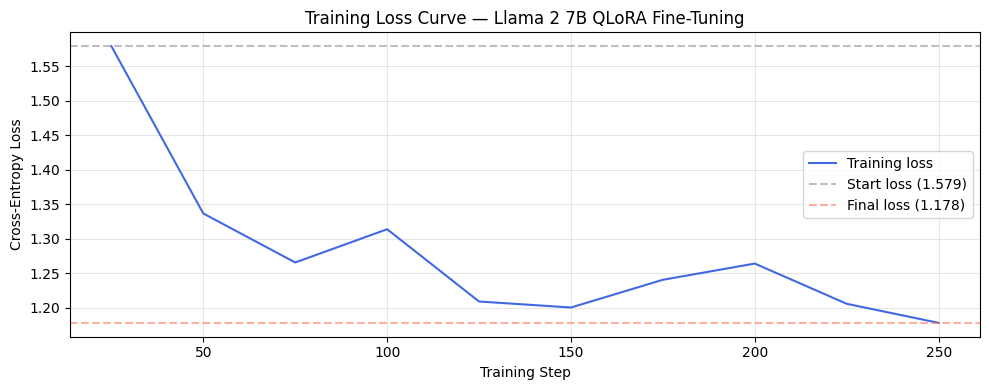

Loss reduction: 1.5794 → 1.1782  (25.4% decrease)


In [18]:
# Extract step-loss pairs from the training log
log_history = trainer.state.log_history
steps  = [entry["step"] for entry in log_history if "loss" in entry]
losses = [entry["loss"] for entry in log_history if "loss" in entry]

if steps:
    plt.figure(figsize=(10, 4))
    plt.plot(steps, losses, color="royalblue", linewidth=1.5, label="Training loss")
    plt.axhline(losses[0], color="gray", linestyle="--", alpha=0.5, label=f"Start loss ({losses[0]:.3f})")
    plt.axhline(losses[-1], color="tomato", linestyle="--", alpha=0.5, label=f"Final loss ({losses[-1]:.3f})")
    plt.xlabel("Training Step")
    plt.ylabel("Cross-Entropy Loss")
    plt.title("Training Loss Curve — Llama 2 7B QLoRA Fine-Tuning")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Loss reduction: {losses[0]:.4f} → {losses[-1]:.4f}  ({(1 - losses[-1]/losses[0])*100:.1f}% decrease)")
else:
    print("No loss data found. Check that logging_steps > 0 in TrainingArguments.")

<a id='16-compare'></a>
## 16. Post-Training Inference & Comparison

We ask the same question we posed in Section 13 and compare the outputs.

The fine-tuned model should show differences in:
- **Tone and style** — the Guanaco dataset has a particular conversational style
- **Answer structure** — may be more or less detailed depending on the dataset
- **Specific vocabulary** — words and phrases that appeared frequently in training

Note: With only 1,000 training examples and 1 epoch, the change may be subtle. More data or more epochs would produce a larger shift.

In [19]:
# Re-enable KV-cache for inference
trainer.model.config.use_cache = True

pipe = pipeline(
    task           = "text-generation",
    model          = trainer.model,
    tokenizer      = tokenizer,
    max_new_tokens = 200,
    do_sample      = False,
)

result_after = pipe(TEST_PROMPT)[0]["generated_text"]

print("=" * 60)
print("BEFORE fine-tuning:")
print("=" * 60)
print(result_before)
print()
print("=" * 60)
print("AFTER fine-tuning:")
print("=" * 60)
print(result_after)

The model 'PeftModelForCausalLM' is not supported for text-generation. Supported models are ['BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'ElectraForCausalLM', 'ErnieForCausalLM', 'FalconForCausalLM', 'FuyuForCausalLM', 'GemmaForCausalLM', 'Gemma2ForCausalLM', 'GitForCausalLM', 'GPT2LMHeadModel', 'GPT2LMHeadModel', 'GPTBigCodeForCausalLM', 'GPTNeoForCausalLM', 'GPTNeoXForCausalLM', 'GPTNeoXJapaneseForCausalLM', 'GPTJForCausalLM', 'JambaForCausalLM', 'JetMoeForCausalLM', 'LlamaForCausalLM', 'MambaForCausalLM', 'Mamba2ForCausalLM', 'MarianForCausalLM', 'MBartForCausalLM', 'MegaForCausalLM', 'MegatronBertForCausalLM', 'MistralForCausalLM', 'MixtralForCausal

BEFORE fine-tuning:
<s>[INST] What is a large language model? [/INST]  A large language model is a type of artificial intelligence (AI) model that is trained on a large dataset of text to generate language outputs that are coherent and natural-sounding. everybody. Large language models are typically trained on vast amounts of text data, such as books, articles, and websites, and are designed to learn the patterns and structures of language.

The goal of a large language model is to be able to generate text that is similar to the training data, and to be able to answer questions, summarize text, and even generate new text that is coherent and natural-sounding. These models are often used in natural language processing (NLP) applications such as language translation, text summarization, and chatbots.

Some examples of large language models include:

1. BERT (Bidirectional Encoder Representations from Transformers): Developed by Google, BERT is a popular large language model that

AFTER f

<a id='17-cleanup'></a>
## 17. Memory Cleanup

### Why do we need to clean up?

To merge the LoRA adapters into the base model, we need to reload the base model in **fp16 precision** (not quantized). This requires ~14 GB of VRAM — much more than the ~5 GB the quantized model occupies.

If we don't delete the old model first, we'll run out of VRAM when trying to load the fp16 version alongside it.

The cleanup order:
1. `del model` / `del trainer` — remove Python references to the model objects
2. `gc.collect()` — run Python's garbage collector to free CPU RAM
3. `torch.cuda.empty_cache()` — tell PyTorch to release cached VRAM back to the OS

In [20]:
# Free memory before reloading in fp16 for merging
del pipe

vram_before_cleanup = torch.cuda.memory_allocated(0) / 1e9
print(f"VRAM before cleanup: {vram_before_cleanup:.2f} GB")

del model
del trainer
gc.collect()
torch.cuda.empty_cache()

vram_after_cleanup = torch.cuda.memory_allocated(0) / 1e9
print(f"VRAM after cleanup : {vram_after_cleanup:.2f} GB")
print(f"Memory freed       : {vram_before_cleanup - vram_after_cleanup:.2f} GB")

VRAM before cleanup: 4.89 GB
VRAM after cleanup : 0.02 GB
Memory freed       : 4.88 GB


<a id='18-merge'></a>
## 18. Merge LoRA Weights into the Base Model

### Why merge?

After training, we have:
- The frozen **base model weights** (W, stored in nf4)
- The trained **LoRA adapter matrices** A and B (stored separately in fp16)

During inference, this means the model must compute `W·x + (α/r)·B·A·x` at every layer — two matrix multiplies instead of one.

**Merging** performs the operation `W_merged = W + (α/r)·B·A` once and saves the result as a single weight matrix. This:
- **Eliminates the runtime overhead** of the adapter (back to one matmul per layer)
- **Makes the model portable** — you no longer need the PEFT library at inference time
- **Allows normal quantization** of the merged model for production deployment

### Why reload in fp16 (not quantized)?

Merging requires performing the addition `W + (α/r)·B·A`. This is a floating-point addition, which requires the weights to be in a standard numeric format.

4-bit NF4 weights are stored on a non-linear grid — you cannot add fp16 values to nf4 values directly. We must reload the base model in fp16 first, then perform the merge in fp16 arithmetic.

The merged model will be in fp16 (~14 GB). If you want to re-quantize it for deployment, you can run a separate quantization step afterwards.

In [21]:
# Step 1: Reload the BASE model in fp16 (no quantization this time)
print("Loading base model in fp16 for merging...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    low_cpu_mem_usage = True,           # Stream weights from disk to avoid peak RAM spike
    torch_dtype       = torch.float16,  # fp16: ~14 GB VRAM for 7B params
    device_map        = {"" : 0},       # Put all layers on GPU 0
)

# Step 2: Load the saved LoRA adapter on top of the base model
print("Attaching LoRA adapter...")
model_with_adapter = PeftModel.from_pretrained(base_model, NEW_MODEL)

# Step 3: Merge adapter weights into base model and unload the adapter
# After this call: model_with_adapter IS the merged model (PeftModel wrapper removed)
print("Merging LoRA weights into base model...")
merged_model = model_with_adapter.merge_and_unload()

vram_after_merge = torch.cuda.memory_allocated(0) / 1e9
print(f"\nMerge complete! VRAM used: {vram_after_merge:.2f} GB")
print("The merged model behaves identically to the fine-tuned model")
print("but requires NO special PEFT libraries at inference time.")

Loading base model in fp16 for merging...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Attaching LoRA adapter...
Merging LoRA weights into base model...

Merge complete! VRAM used: 13.49 GB
The merged model behaves identically to the fine-tuned model
but requires NO special PEFT libraries at inference time.


<a id='19-save'></a>
## 19. Save & (Optional) Push to Hugging Face Hub

### Saving locally

`save_pretrained()` saves:
- `pytorch_model.bin` or `model.safetensors` — the weight tensors
- `config.json` — the model architecture configuration
- `tokenizer.json`, `tokenizer_config.json`, `special_tokens_map.json` — the tokenizer files

The saved directory is everything you need to reload and run the model with `AutoModelForCausalLM.from_pretrained("./your-model-name")`.

### Pushing to the Hugging Face Hub

The Hub is a public (or private) model registry where you can share model weights. To push:
1. Create a free account at [huggingface.co](https://huggingface.co)
2. Generate an access token with write permissions
3. Run `huggingface-cli login` or set the `HUGGING_FACE_HUB_TOKEN` environment variable

The `push_to_hub()` call below is wrapped in a comment block — uncomment it only if you want to publish the model.

In [22]:

import os

# If Google Drive is mounted, save directly there; otherwise use local directory
SAVE_DIR = os.path.join(
    os.path.dirname(NEW_MODEL) if USE_DRIVE else ".",
    "Llama-2-7b-chat-finetune_merged"
)

print(f"Saving merged model to: {SAVE_DIR}")
merged_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# List what was saved
saved_files = os.listdir(SAVE_DIR)
print(f"\nSaved files in '{SAVE_DIR}':")
for f in sorted(saved_files):
    size_mb = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1e6
    print(f"  {f:50s}  {size_mb:.1f} MB")

print(f"\nTo reload this model later:")
print(f'  model = AutoModelForCausalLM.from_pretrained("{SAVE_DIR}")')
print(f'  tokenizer = AutoTokenizer.from_pretrained("{SAVE_DIR}")')
if USE_DRIVE:
    print(f"\n✓  Model saved to Google Drive — it will persist after this session ends.")
else:
    print(f"\n⚠️  On Colab without Drive: this file will be lost when the session ends.")
    print(f"   Download it via Files panel (left sidebar) or set USE_DRIVE=True.")


Saving merged model to: Llama-2-7b-chat-finetune_merged

Saved files in 'Llama-2-7b-chat-finetune_merged':
  added_tokens.json                                   0.0 MB
  config.json                                         0.0 MB
  generation_config.json                              0.0 MB
  model-00001-of-00003.safetensors                    4939.0 MB
  model-00002-of-00003.safetensors                    4947.4 MB
  model-00003-of-00003.safetensors                    3590.5 MB
  model.safetensors.index.json                        0.0 MB
  special_tokens_map.json                             0.0 MB
  tokenizer.json                                      1.8 MB
  tokenizer.model                                     0.5 MB
  tokenizer_config.json                               0.0 MB

To reload this model later:
  model = AutoModelForCausalLM.from_pretrained("Llama-2-7b-chat-finetune_merged")
  tokenizer = AutoTokenizer.from_pretrained("Llama-2-7b-chat-finetune_merged")

✓  Model saved to Goog

In [23]:
# ─── OPTIONAL: Push to Hugging Face Hub ────────────────────────────────────
# Uncomment the lines below ONLY if you have an HF account and write token.
# Replace 'your-username' with your actual Hugging Face username.

# HF_USERNAME = "your-username"
# HUB_MODEL_ID = f"{HF_USERNAME}/{NEW_MODEL}"
#
# from huggingface_hub import login
# login()  # Will prompt for your HF token
#
# merged_model.push_to_hub(HUB_MODEL_ID, use_temp_dir=False)
# tokenizer.push_to_hub(HUB_MODEL_ID)
#
# print(f"Model pushed to: https://huggingface.co/{HUB_MODEL_ID}")

print("Hub push step skipped (commented out). Uncomment to publish your model.")

Hub push step skipped (commented out). Uncomment to publish your model.


<a id='20-references'></a>
## 20. References & Further Reading

### Papers

**[1] LoRA: Low-Rank Adaptation of Large Language Models**  
Hu, E., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., & Chen, W. (2022).  
arXiv:2106.09685  
*The original LoRA paper. Read this first — it's well-written and the math is approachable.*

**[2] QLoRA: Efficient Finetuning of Quantized LLMs**  
Dettmers, T., Pagnoni, A., Holtzman, A., & Zettlemoyer, L. (2023).  
arXiv:2305.14314  
*Introduces NF4 quantization, double quantization, and paged optimizers. The foundation of this notebook.*

**[3] Llama 2: Open Foundation and Fine-Tuned Chat Models**  
Touvron, H., Martin, L., Stone, K., et al. (2023).  
arXiv:2307.09288  
*The model we fine-tune. Describes the architecture, training procedure, and safety alignment.*

**[4] OpenAssistant Conversations — Democratizing Large Language Model Alignment**  
Köpf, A., Kilcher, Y., von Rütte, D., et al. (2023).  
arXiv:2304.07327  
*The source of the Guanaco dataset used in this notebook.*

**[5] Training Language Models to Follow Instructions with Human Feedback (InstructGPT)**  
Ouyang, L., Wu, J., Jiang, X., et al. (2022).  
arXiv:2203.02155  
*The seminal paper on RLHF — the broader context in which fine-tuning chat models sits.*

---

### Libraries & Documentation

**[6] Hugging Face PEFT library**  
Documentation: https://huggingface.co/docs/peft  
*API reference for `LoraConfig`, `PeftModel`, `get_peft_model`, and all other PEFT methods.*

**[7] Hugging Face TRL library (SFTTrainer)**  
Documentation: https://huggingface.co/docs/trl  
*API reference for `SFTTrainer`, `RewardTrainer`, `PPOTrainer` (for RLHF).*

**[8] bitsandbytes documentation**  
Documentation: https://huggingface.co/docs/bitsandbytes  
*Reference for `BitsAndBytesConfig` and the underlying quantization implementation.*

**[9] Hugging Face Accelerate**  
Documentation: https://huggingface.co/docs/accelerate  
*Distributed training and device management — used under the hood by the Trainer.*

---

### Connection to This Curriculum

| Concept used here | Where you first learned it |
|---|---|
| Gradient descent & chain rule | `1. derivatives.ipynb`, `3. gradient.ipynb` |
| Matrix multiplication | `4. matrix.ipynb`, `tensors_1.ipynb` |
| Weight initialisation (Xavier/He) | `neural_network/2_multi_neuron_layers_&_math.ipynb` |
| Low-rank factorisation (LoRA = ΔW = BA) | `neural_network/2_multi_neuron_layers_&_math.ipynb` |
| Cross-entropy loss | `neural_network/neuron_layers.ipynb` |
| Attention & transformer architecture | `neural_network/2_multi_neuron_layers_&_math.ipynb` |
| Batch normalisation | `neural_network/2_multi_neuron_layers_&_math.ipynb` |

---

### What to Try Next

1. **Increase dataset size:** Switch `DATASET_ID` to `"mlabonne/guanaco-llama2"` (~10k examples) and observe the quality improvement
2. **Vary LoRA rank:** Try `LORA_R = 8` vs `LORA_R = 128` — measure training time, VRAM, and output quality
3. **Try a different base model:** Swap `MODEL_ID` to `"mistralai/Mistral-7B-Instruct-v0.3"` — same code, different model family
4. **Add validation split:** Compute val loss per epoch to monitor for overfitting
5. **RLHF / DPO:** After SFT, apply Direct Preference Optimisation (`trl.DPOTrainer`) to align the model with human preferences — the next step beyond supervised fine-tuning